In [3]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

sys.path.append("../../../..")

current = Path().resolve()
sys.path.append(str(current))
sys.path.append(str(current.parents[2]))

from src.enums import *
from src.utils import *
from src.market_data import *
from src.pricer import *

MarketData.initialize()

QuantCourseBP d01024446823f086eeca30bc41c118bfc50eb864*


Vol: 0.1 | MM ár: 3.6791 | MC ár: 3.6827
Vol: 0.2 | MM ár: 5.8299 | MC ár: 5.8339
Vol: 0.3 | MM ár: 8.0557 | MC ár: 8.0477
Vol: 0.4 | MM ár: 10.3095 | MC ár: 10.2760
Vol: 0.5 | MM ár: 12.5846 | MC ár: 12.5056
Vol: 0.6 | MM ár: 14.8807 | MC ár: 14.7295
Vol: 0.7 | MM ár: 17.1996 | MC ár: 16.9430
Vol: 0.8 | MM ár: 19.5436 | MC ár: 19.1440
Vol: 0.9 | MM ár: 21.9150 | MC ár: 21.3280
Vol: 1.0 | MM ár: 24.3158 | MC ár: 23.4929


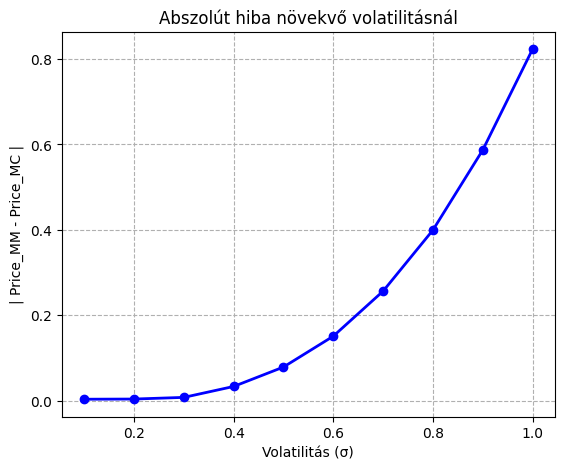

In [9]:
und = Stock.TEST_COMPANY
model = BSVolModel(und)
spot = model.spot
strk = 100
exp = 1
num_mon = 100
contract = AsianContract(und, PutCallFwd.CALL, LongShort.LONG, strk, exp, num_mon)

vol_list = np.linspace(0.1, 1.0, 10)

price_MM_list = []
price_MC_list = []

params_MC = MCParams(seed=11, num_of_path=20000, tenor_frequency=1)

for vol in vol_list:
    
    model_sim = copy.deepcopy(model)
    
    model_sim.get_vol = lambda strike, expiry: vol

    pricer_MM = AsianMomentMatchingPricer(contract, model_sim, Params())
    pv_MM = pricer_MM.calc_fair_value()
    price_MM_list.append(pv_MM)
    

    pricer_MC = GenericMCPricer(contract, model_sim, params_MC)
    pv_MC_tuple = pricer_MC.calc_fair_value_with_ci()
    price_MC_list.append(pv_MC_tuple)
    
    print(f"Vol: {vol:.1f} | MM ár: {pv_MM:.4f} | MC ár: {pv_MC_tuple[0]:.4f}")

abs_errors = [abs(price_MM_list[i] - price_MC_list[i][0]) for i in range(len(vol_list))]

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(vol_list, abs_errors, marker='o', color='blue', linewidth=2)
plt.title('Abszolút hiba növekvő volatilitásnál')
plt.xlabel('Volatilitás (\u03c3)')
plt.ylabel('| Price_MM - Price_MC |')
plt.grid(True, linestyle='--')

Megfigyelések (n):    5 | MM ár: 9.2504 | MC ár: 9.3751
Megfigyelések (n):   25 | MM ár: 8.2449 | MC ár: 8.3039
Megfigyelések (n):   50 | MM ár: 8.1188 | MC ár: 8.1796
Megfigyelések (n):  100 | MM ár: 8.0557 | MC ár: 8.1437
Megfigyelések (n):  250 | MM ár: 8.0178 | MC ár: 7.8968
Megfigyelések (n):  500 | MM ár: 8.0051 | MC ár: 7.9876


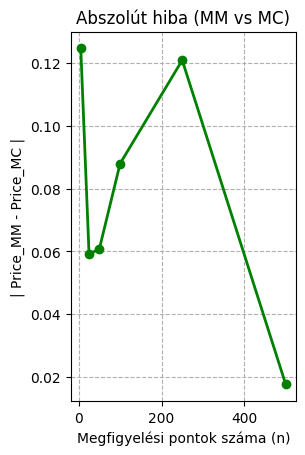

In [14]:
params_MC = MCParams(seed=11, num_of_path=10000, tenor_frequency=1)

num_mon_list = [5, 25, 50, 100, 250, 500]

price_MM_list = []
price_MC_list = []

for n in num_mon_list:
    
    contract = AsianContract(und, PutCallFwd.CALL, LongShort.LONG, strk, exp, n)
    
    pricer_MM = AsianMomentMatchingPricer(contract, model, Params())
    pv_MM = pricer_MM.calc_fair_value()
    price_MM_list.append(pv_MM)
    
    pricer_MC = GenericMCPricer(contract, model, params_MC)
    pv_MC = pricer_MC.calc_fair_value_with_ci()
    price_MC_list.append(pv_MC)
    
    print(f"Megfigyelések (n): {n:4d} | MM ár: {pv_MM:.4f} | MC ár: {pv_MC[0]:.4f}")

abs_errors = [abs(price_MM_list[i] - price_MC_list[i][0]) for i in range(len(num_mon_list))]

plt.subplot(1, 2, 1)
plt.plot(num_mon_list, abs_errors, marker='o', color='green', linewidth=2)
plt.title('Abszolút hiba (MM vs MC)')
plt.xlabel('Megfigyelési pontok száma (n)')
plt.ylabel('| Price_MM - Price_MC |')
plt.grid(True, linestyle='--')

According to the Central Limit Theorem, as the number of averaging points tends to infinity, the true distribution of the arithmetic average approaches a Normal distribution. However, the Moment Matching method assumes that this average follows a Lognormal distribution. Consequently, the lognormal approximation becomes increasingly inaccurate as n tends to infinity, leading to a growing pricing error.